In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/drw-crypto-market-prediction/sample_submission.csv
/kaggle/input/drw-crypto-market-prediction/train.parquet
/kaggle/input/drw-crypto-market-prediction/test.parquet


In [2]:
!rm -rf /kaggle/working/crypto_market_prediction
!git clone https://github.com/CapstoneTeam23UMICH/crypto_market_prediction.git
!pip install -r /kaggle/working/crypto_market_prediction/requirements.txt

Cloning into 'crypto_market_prediction'...
remote: Enumerating objects: 3241, done.
remote: Counting objects: 100% (3110/3110), done.
remote: Compressing objects: 100% (2089/2089), done.
remote: Total 3241 (delta 601), reused 3037 (delta 567), pack-reused 131 (from 1)
Receiving objects: 100% (3241/3241), 30.06 MiB | 32.58 MiB/s, done.
Resolving deltas: 100% (652/652), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 100.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 74.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 77.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 74.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━

In [ ]:
import sys
import pandas as pd
import numpy as np
import lightgbm as lgb
import mlflow
import plotly.graph_objects as go

sys.path.append('/kaggle/working/crypto_market_prediction')

from src.github_push_folder import push_folder_to_github

from src.get_refresh_metadata import (
    get_feature_drift_df,
    get_correlation_train_df,
    get_correlation_test_df,
    get_autocorrelation_train_df,
    get_adversarial_validation_df,
    get_mutual_information_train_df,
    get_correlation_stability_df,
    get_vif_train_df)

from src.get_feature_set import get_feature_set

from src.run_cv import run_grid_search


df_drift = get_feature_drift_df()
df_corr_train = get_correlation_train_df()
df_autocorr = get_autocorrelation_train_df()
df_adv_val = get_adversarial_validation_df()
df_mutual_information = get_mutual_information_train_df()
df_corr_stability = get_correlation_stability_df()
df_vif = get_vif_train_df()

Loading existing df_feature_drift.parquet
Loading existing corr_long_train.parquet
Loading existing autocorr_long_train.parquet
Loading existing df_adversarial_validation.parquet
Loading existing df_mutual_information_train.parquet
Loading existing df_corr_stability.parquet
Loading existing df_vif.parquet


In [5]:
train_path = '/kaggle/input/drw-crypto-market-prediction/train.parquet'
test_path = '/kaggle/input/drw-crypto-market-prediction/test.parquet'

df_train = pd.read_parquet(train_path).astype('float32')
df_test = pd.read_parquet(test_path).astype('float32')

In [6]:
known_features = ['bid_qty', 'ask_qty', 'buy_qty', 'sell_qty', 'volume']
target = 'label'
anonymized_features = sorted(list(set(df_train.columns) - set(known_features) - set([target])), key=lambda x: int(x[1:]))
selected_features = get_feature_set(anonymized_features, corr_thresh = 0.99, vif_tresh = 100, mi_tresh = 0.02)

Loading existing df_feature_drift.parquet
Loading existing corr_long_train.parquet
Loading existing autocorr_long_train.parquet
Loading existing df_adversarial_validation.parquet
Loading existing df_mutual_information_train.parquet
Loading existing df_vif.parquet
Returning Features Set of Size: 236


invalid value encountered in less


## Running Model Grid Search & Push to Github

In [ ]:
for i in ['MLP','XGB','LBGM']:
    result = run_grid_search(
        'MLP',
        df_train,
        selected_features,
        target="label",
        mode="find_best_model",
        tracking_uri= "/kaggle/working/crypto_market_prediction/mlruns",
        experiment_name = 'regression_grid_search',
    )

push_folder_to_github(
    repo_path="/kaggle/working/crypto_market_prediction",
    folder_to_commit="mlruns",
    commit_msg = "Add experiments for regression grid search",
    new_branch = 'mlruns/add-experiment-for-regression-grid-search-2',
    github_token = github_token,
    github_user=github_user,
    github_email=github_email,
    repo_name="crypto_market_prediction",
    base_branch="main"
)

In [7]:
result = run_grid_search(
    'classifier_SAE',
    df_train,
    selected_features,
    target="label",
    mode="find_best_model",
    tracking_uri= "/kaggle/working/crypto_market_prediction/mlruns",
    experiment_name = 'autoencoder_grid_search',
)

push_folder_to_github(
    repo_path="/kaggle/working/crypto_market_prediction",
    folder_to_commit="mlruns",
    commit_msg = "Add experiments for autoencoder grid search 2",
    new_branch = 'mlruns/add-experiment-for-autoencoder-grid-search-8',
    github_token = github_token,
    github_user=github_user,
    github_email=github_email,
    repo_name="crypto_market_prediction",
    base_branch="main"
)

2025/08/12 14:10:30 INFO mlflow.tracking.fluent: Experiment with name 'autoencoder_grid_search' does not exist. Creating a new experiment.
Running search for classifier_SAE: 100%|██████████| 32/32 [28:03<00:00, 52.61s/it]


In [7]:
df_sensitivity = run_grid_search(
    'MLP',
    df_train,
    selected_features,
    target="label",
    mode="sensitivity_analysis",
    tracking_uri= "/kaggle/working/crypto_market_prediction/mlruns",
    experiment_name = 'regression_sensitivity_analysis',
)

push_folder_to_github(
    repo_path="/kaggle/working/crypto_market_prediction",
    folder_to_commit="mlruns",
    commit_msg = "Add experiments for regression sensitvity analysis",
    new_branch = 'mlruns/add-experiment-for-regression-sensitivity',
    github_token = github_token,
    github_user=github_user,
    github_email=github_email,
    repo_name="crypto_market_prediction",
    base_branch="main"
)

2025/08/14 10:59:15 INFO mlflow.tracking.fluent: Experiment with name 'regression_sensitivity_analysis' does not exist. Creating a new experiment.
Running search for MLP: 100%|██████████| 49/49 [22:21<00:00, 27.38s/it]


## Hyperparameter Sensitivity Analysis

In [ ]:
mlflow.set_tracking_uri("/kaggle/working/crypto_market_prediction/mlruns")
experiment_name = "regression_sensitivity_analysis"
experiment = mlflow.get_experiment_by_name(experiment_name)

runs_df = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    output_format="pandas"
)


In [ ]:
def plot_sensitivity_surface(
    runs_df,
    model_key="MLP",
    metric_col="metrics.mean_pearson_test",
    lr_col="params.lr",
    wd_col="params.weight_decay",
    annotate_best=True,
    height=720
):
    df = runs_df[runs_df["params.model_key"] == model_key][[lr_col, wd_col, metric_col]].dropna()
    zmat = (
        df.pivot(index=wd_col, columns=lr_col, values=metric_col)
          .sort_index()
          .sort_index(axis=1)
    )

    X = zmat.columns.to_numpy(dtype=float)
    Y = zmat.index.to_numpy(dtype=float)
    Z = zmat.to_numpy(dtype=float)
    z_span = float(np.nanmax(Z) - np.nanmin(Z)) if np.isfinite(Z).all() else 1.0
    dz = max(z_span * 0.02, 1e-6)

    fig = go.Figure()

    fig.add_trace(go.Surface(
        x=X, y=Y, z=Z,
        colorscale="Viridis",
        showscale=False,
        opacity=0.97,
        lighting=dict(ambient=0.55, diffuse=0.75, specular=0.2, roughness=0.5, fresnel=0.1),
        lightposition=dict(x=1.5, y=1.5, z=2.0)
    ))

    if annotate_best:
        iy, ix = np.unravel_index(np.nanargmax(Z), Z.shape)
        bx, by, bz = float(X[ix]), float(Y[iy]), float(Z[iy, ix])
        fig.add_trace(go.Scatter3d(
            x=[bx], y=[by], z=[bz + dz],
            mode="markers+text",
            marker=dict(size=7, color="black", symbol="circle-open"),
            text=[f"<b>best={bz:.4f}</b><br>lr={bx:.5g}, wd={by:.5g}"],
            textposition="top center",
            textfont=dict(size=12),
            showlegend=False,
            name="best"
        ))

    fig.update_layout(
        height=height,
        margin=dict(l=10, r=10, t=10, b=10),
        paper_bgcolor="white",
        font=dict(family="Arial, Helvetica, sans-serif", size=12),
        scene=dict(
            xaxis=dict(
                title="Learning rate",
                tickformat=".3g",
                gridcolor="#e6e6e6",
                zeroline=False
            ),
            yaxis=dict(
                title="Weight decay",
                tickformat=".3g",
                gridcolor="#e6e6e6",
                zeroline=False
            ),
            zaxis=dict(
                title="Evaluation metric",
                tickformat=".4g",
                gridcolor="#e6e6e6",
                zeroline=False
            ),
            camera=dict(eye=dict(x=1.8, y=1.8, z=1.2)),
            aspectmode="cube"
        ),
        showlegend=False
    )

    fig.show()

plot_sensitivity_surface(runs_df, 
                         "MLP", 
                         "metrics.mean_pearson_test", 
                         "params.lr", 
                         "params.weight_decay")

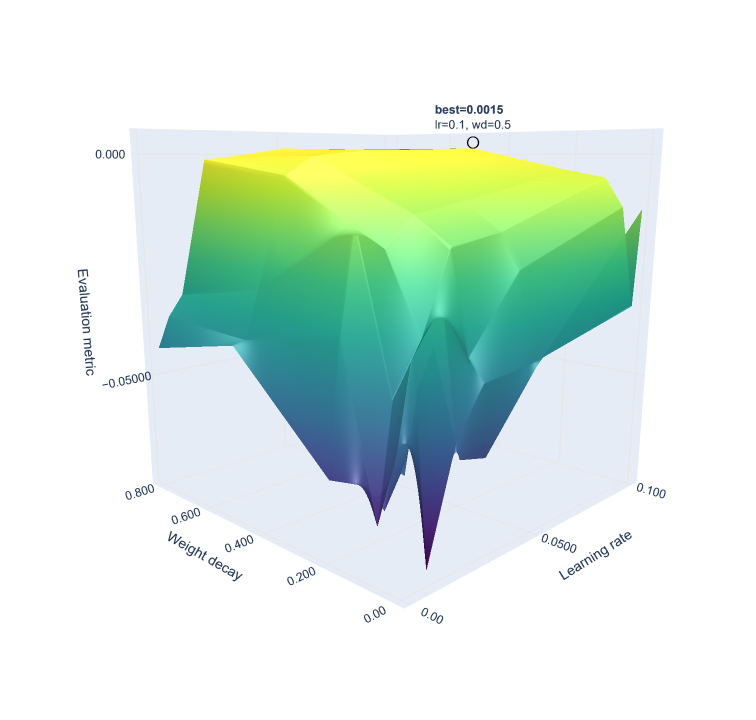 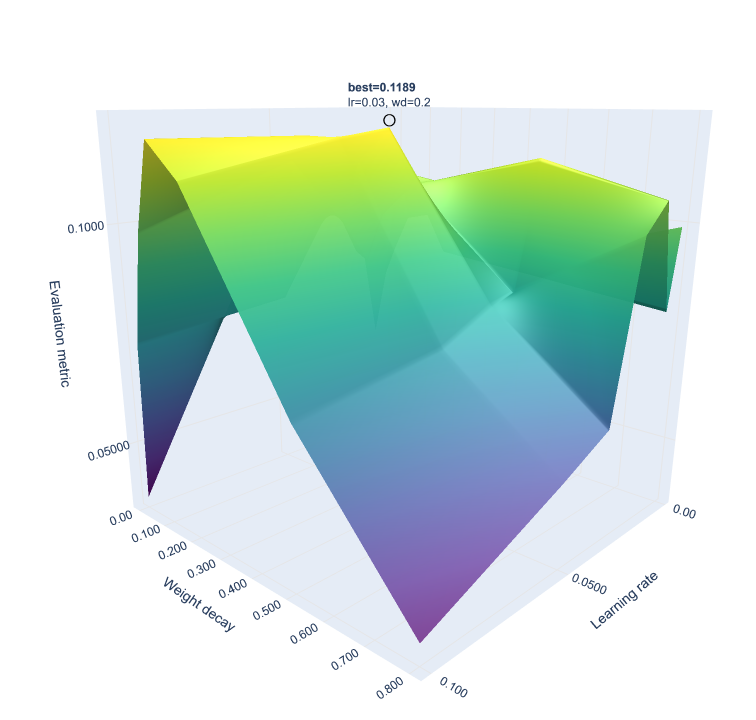